In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('/content/SUSTAINABILITY IN CORPORATE (Responses) - Form responses 1.csv')

# Initial inspection
print("Original dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types and missing values:")
print(df.info())

# 1. Handling Missing Values
# Replace empty strings with NaN
df.replace('', np.nan, inplace=True)
df.replace(' ', np.nan, inplace=True)
df.replace('No', np.nan, inplace=True)  # Assuming 'No' in short answer means no response
df.replace('Not sure', np.nan, inplace=True)

# Check missing values after initial cleaning
print("\nMissing values after initial cleaning:")
print(df.isnull().sum())

# 2. Standardizing Categorical Data
# Clean and standardize categorical columns
categorical_cols = [
    'How often do you consider a company\'s sustainability efforts before purchasing its products/services?',
    'What influences your decision to support a company based on sustainability?',
    'Which industries should focus more on circular economy principles?',
    'In your opinion, where can AI contribute most to sustainability?',
    'What challenges do you foresee in adopting AI for sustainability?',
    'Do you think SMEs (Small and Medium Enterprises) face more challenges than large corporations in adopting sustainability?',
    'What are the biggest barriers to sustainability adoption in SMEs (Small and Medium Enterprises)?',
    'What would help SMEs (Small and Medium Enterprises) integrate sustainability into their business?',
    'Do you believe corporations influence government sustainability policies?',
    'What role should governments play in ensuring corporate sustainability?',
    'What factors make sustainable finance investments attractive to businesses?'
]

for col in categorical_cols:
    if col in df.columns:
        # Remove leading/trailing whitespace
        df[col] = df[col].str.strip()
        # Standardize capitalization
        df[col] = df[col].str.title()

# 3. Cleaning Numerical Columns
# Clean percentage columns
percent_cols = [
    'What percentage of your purchases are from companies that follow sustainability practices?',
    'What is the estimated increase in productivity you experience due to sustainability initiatives at your workplace?'
]

for col in percent_cols:
    if col in df.columns:
        # Remove percentage signs and convert to float
        df[col] = df[col].astype(str).str.replace('%', '')
        # Convert to numeric, coerce errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Cap at 100% if any values exceed it
        df[col] = df[col].apply(lambda x: min(x, 100) if x > 100 else x)

# 4. Cleaning Text Responses
text_cols = [
    'In your opinion, what\'s the biggest missing piece in corporate sustainability efforts today? (Short answer response)',
    'What specific challenges do SMEs face in balancing profitability and sustainability, and how can they overcome them? (Short answer response)'
]

for col in text_cols:
    if col in df.columns:
        # Basic text cleaning
        df[col] = df[col].str.strip()
        df[col] = df[col].str.title()
        # Replace empty strings with NaN
        df[col].replace('', np.nan, inplace=True)

# 5. Handling Duplicate Columns
# Check for duplicate email addresses (potential duplicate responses)
print("\nDuplicate email addresses:")
print(df['Email address'].duplicated().sum())

# 6. Encoding Categorical Variables
# For machine learning, we might want to encode some categorical variables
label_encoder = LabelEncoder()
for col in categorical_cols:
    if col in df.columns:
        df[col+'_encoded'] = label_encoder.fit_transform(df[col].astype(str))

# Final cleaned dataset inspection
print("\nCleaned dataset shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Save cleaned data
df.to_csv('cleaned_sustainability_survey.csv', index=False)
print("\nCleaned data saved to 'cleaned_sustainability_survey.csv'")

Original dataset shape: (45, 19)

First few rows:
             Timestamp                  Email address                  Name  \
0  17/03/2025 17:55:24        atharvanaik44@gmail.com              Atharva    
1  18/03/2025 19:20:19       padmadarbarwar@gmail.com       Padma darbarwar   
2  18/03/2025 20:01:19    santoshdarbarwar9@gmail.com    Santosh Darbarwar    
3  18/03/2025 20:12:18       poojaachawan30@gmail.com         Pooja Chawan    
4  18/03/2025 21:03:00  shivkumar.darbarwar@gmail.com  Shivkumar Darbarwar    

                           Email  \
0        atharvanaik44@gmail.com   
1       padmadarbarwar@gmail.com   
2   santosh.darbarwar9@gmail.com   
3        poojapatil7@hotmail.com   
4  shivkumar.darbarwar@gmail.com   

  How often do you consider a company’s sustainability efforts before purchasing its products/services?  \
0                                              Often                                                      
1                                           

<ipython-input-1-f1a886af419f>:77: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace('', np.nan, inplace=True)


<ipython-input-2-e42238a60388>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


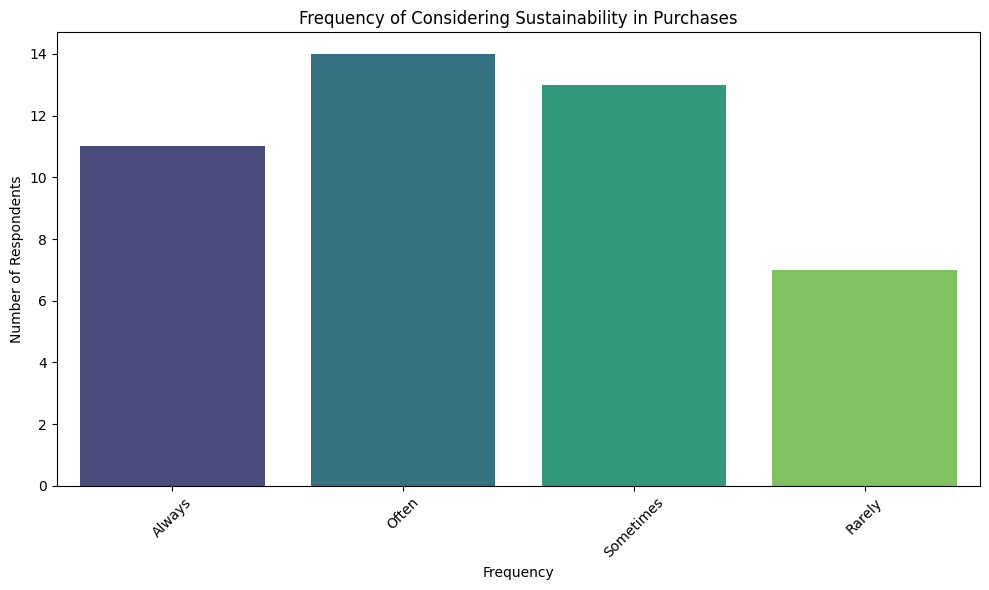

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_sustainability_survey.csv')

plt.figure(figsize=(10, 6))
sns.countplot(data=df,
             x='How often do you consider a company’s sustainability efforts before purchasing its products/services?',
             order=['Always', 'Often', 'Sometimes', 'Rarely'],
             palette="viridis")
plt.title("Frequency of Considering Sustainability in Purchases")
plt.xlabel("Frequency")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

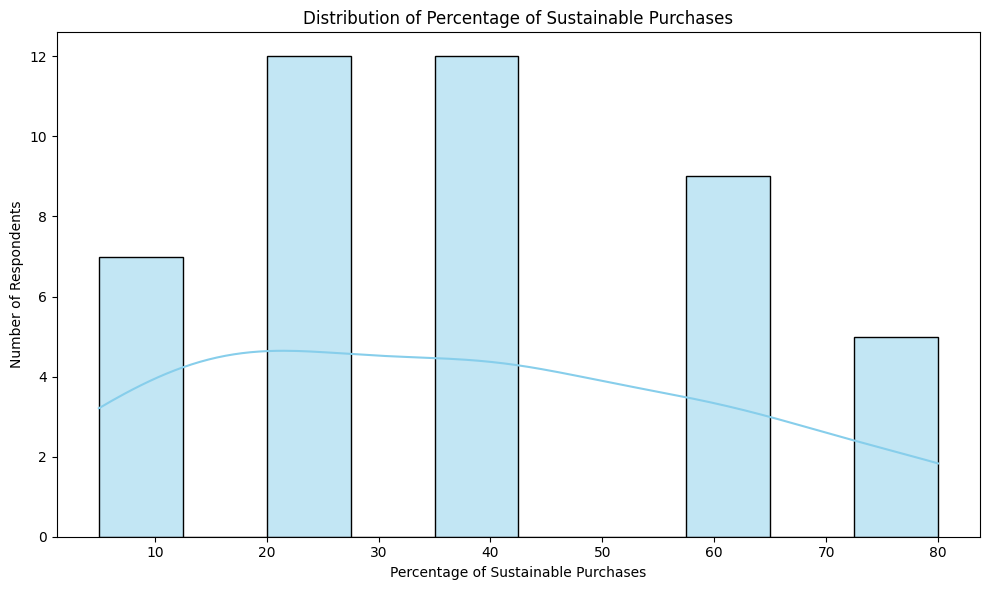

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df,
            x='What percentage of your purchases are from companies that follow sustainability practices?',
            bins=10,
            kde=True,
            color='skyblue')
plt.title("Distribution of Percentage of Sustainable Purchases")
plt.xlabel("Percentage of Sustainable Purchases")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

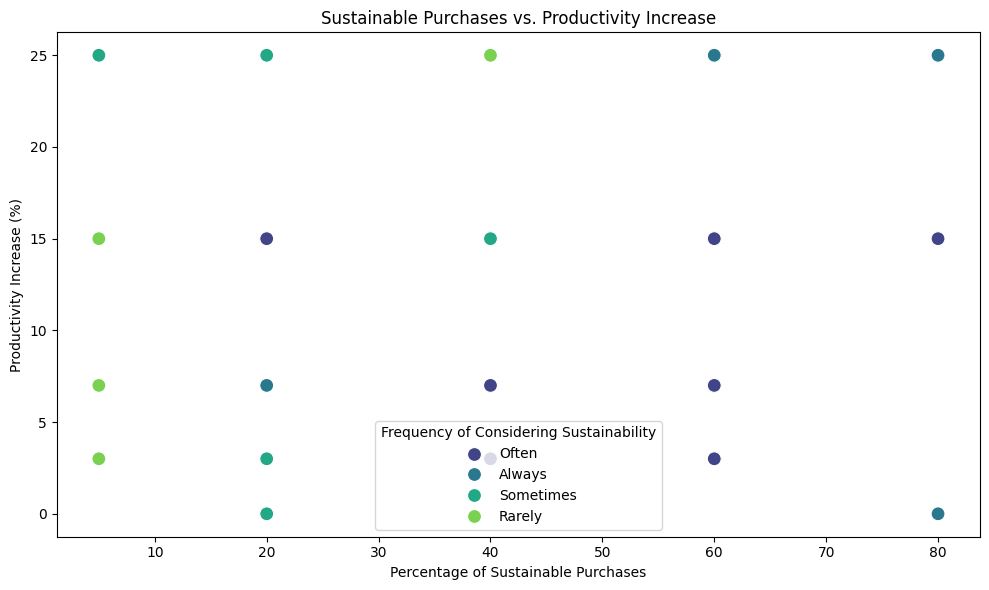

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
               x='What percentage of your purchases are from companies that follow sustainability practices?',
               y='What is the estimated increase in productivity you experience due to sustainability initiatives at your workplace?',
               hue='How often do you consider a company’s sustainability efforts before purchasing its products/services?',
               palette="viridis",
               s=100)
plt.title("Sustainable Purchases vs. Productivity Increase")
plt.xlabel("Percentage of Sustainable Purchases")
plt.ylabel("Productivity Increase (%)")
plt.legend(title='Frequency of Considering Sustainability')
plt.tight_layout()
plt.show()

<ipython-input-5-136baef56446>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.values,


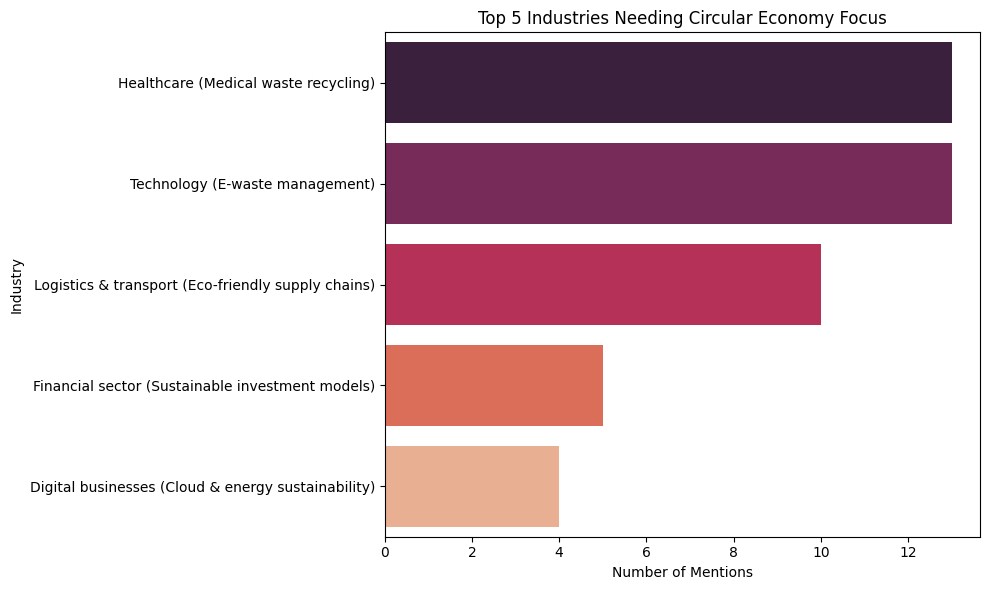

In [ ]:
plt.figure(figsize=(10, 6))
industry_counts = df['Which industries should focus more on circular economy principles? '].value_counts().nlargest(5)
sns.barplot(x=industry_counts.values,
            y=industry_counts.index,
            palette="rocket")
plt.title("Top 5 Industries Needing Circular Economy Focus")
plt.xlabel("Number of Mentions")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

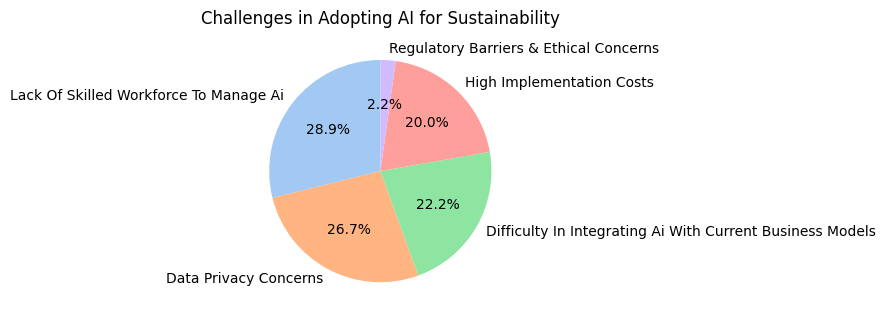

In [ ]:
plt.figure(figsize=(8, 8))
ai_challenges = df['What challenges do you foresee in adopting AI for sustainability?'].value_counts()
plt.pie(ai_challenges,
       labels=ai_challenges.index,
       autopct='%1.1f%%',
       startangle=90,
       colors=sns.color_palette("pastel"),
       textprops={'fontsize': 10})
plt.title("Challenges in Adopting AI for Sustainability")
plt.tight_layout()
plt.show()

<ipython-input-7-f82fecd6fbb6>:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


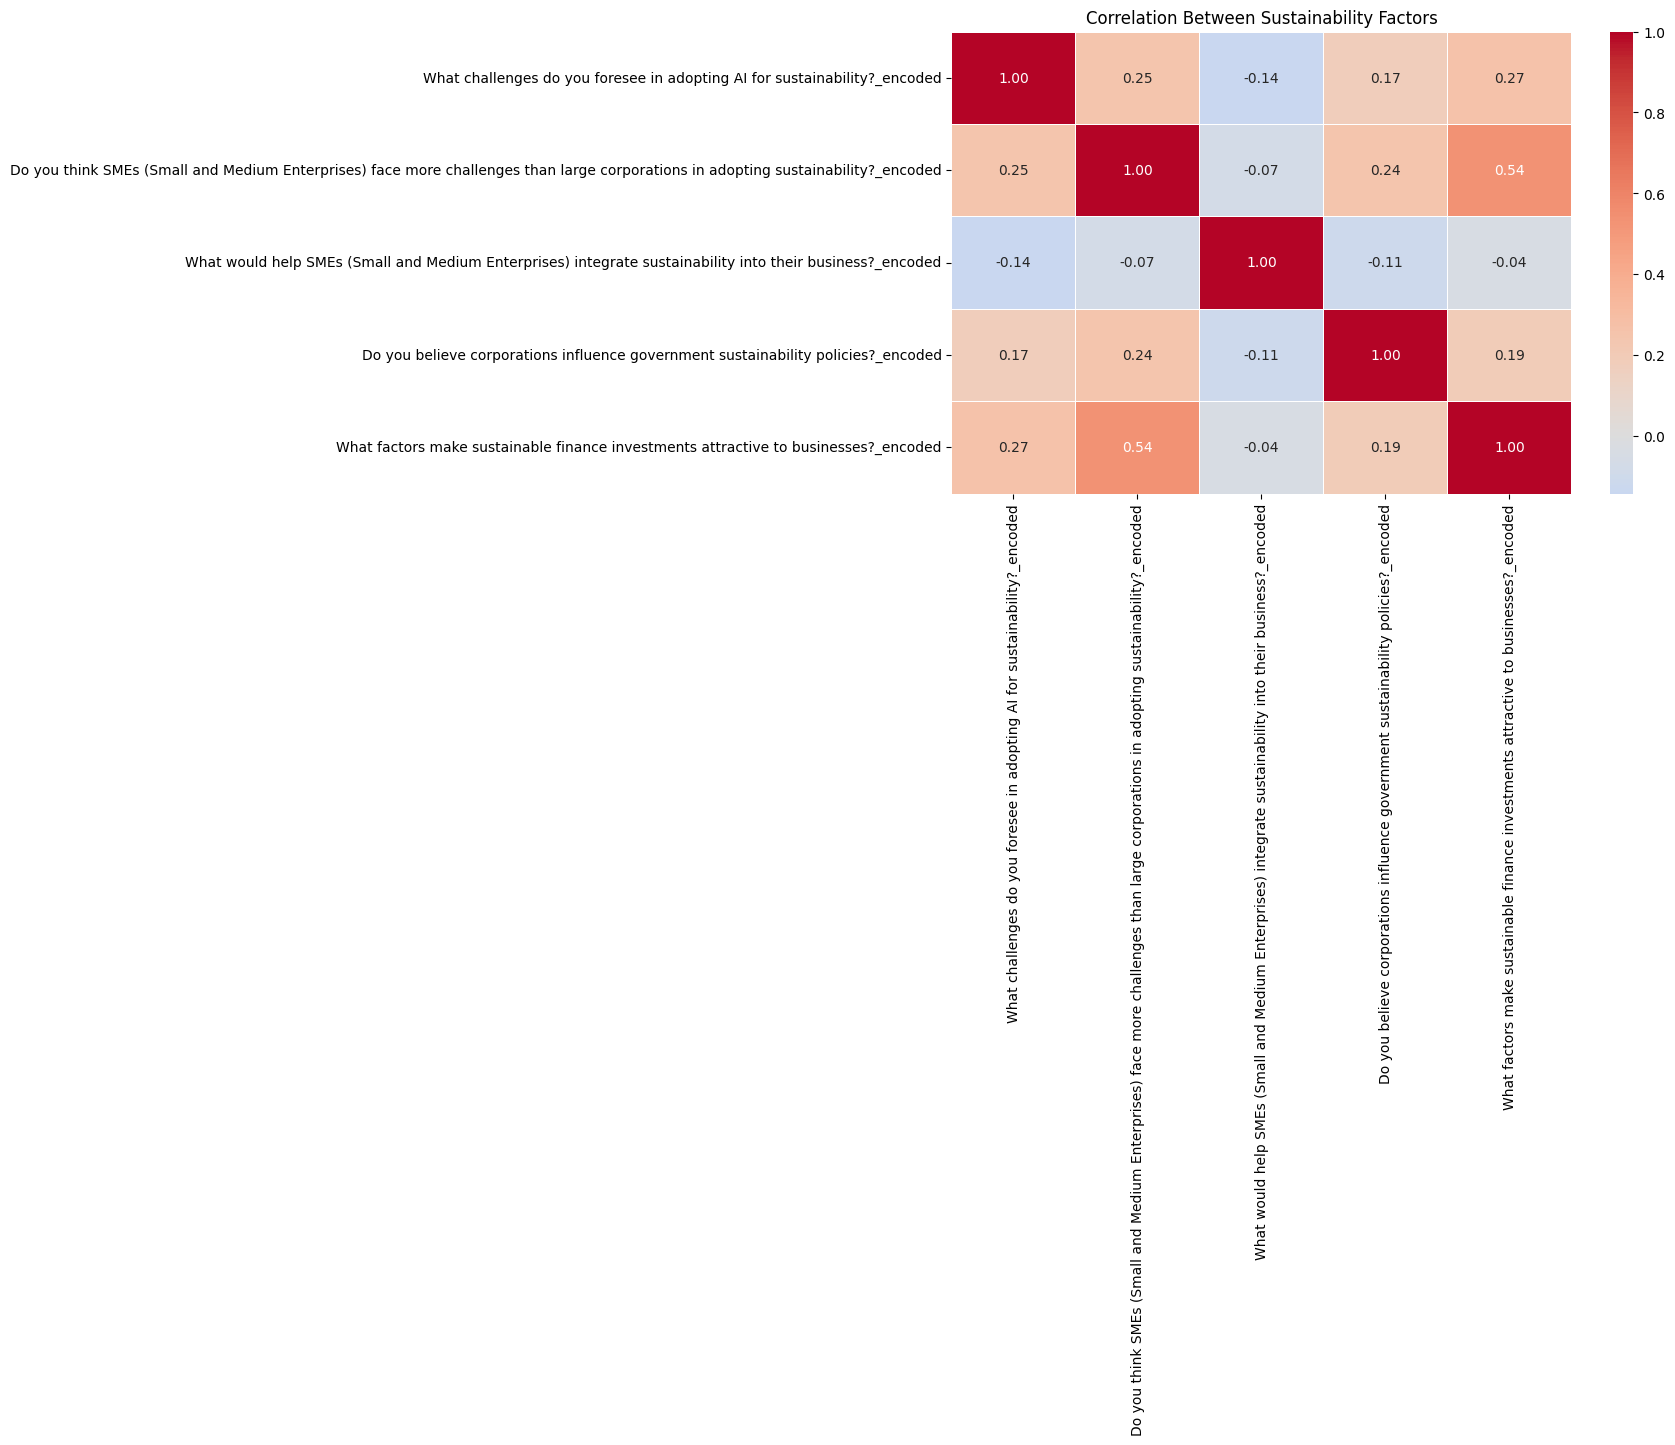

In [ ]:
encoded_cols = [col for col in df.columns if '_encoded' in col]
plt.figure(figsize=(10, 6))
sns.heatmap(df[encoded_cols].corr(),
           annot=True,
           cmap="coolwarm",
           center=0,
           fmt=".2f",
           linewidths=.5)
plt.title("Correlation Between Sustainability Factors")
plt.tight_layout()
plt.show()

<ipython-input-8-4b986cd1795c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


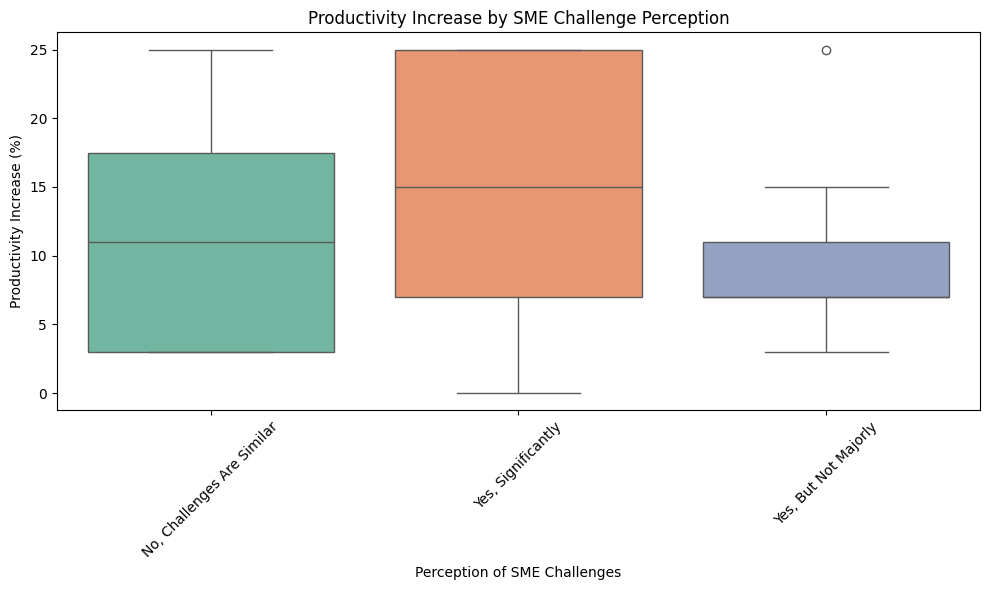

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df,
           x='Do you think SMEs (Small and Medium Enterprises) face more challenges than large corporations in adopting sustainability?',
           y='What is the estimated increase in productivity you experience due to sustainability initiatives at your workplace?',
           palette="Set2")
plt.title("Productivity Increase by SME Challenge Perception")
plt.xlabel("Perception of SME Challenges")
plt.ylabel("Productivity Increase (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Available columns in the dataset:
['Timestamp', 'Email address', 'Name', 'Email', 'How often do you consider a company’s sustainability efforts before purchasing its products/services?', 'What influences your decision to support a company based on sustainability? ', 'What percentage of your purchases are from companies that follow sustainability practices?', 'What is the estimated increase in productivity you experience due to sustainability initiatives at your workplace?', 'Which industries should focus more on circular economy principles? ', 'In your opinion, where can AI contribute most to sustainability? ', 'What challenges do you foresee in adopting AI for sustainability?', 'Do you think SMEs (Small and Medium Enterprises) face more challenges than large corporations in adopting sustainability?', 'What are the biggest barriers to sustainability adoption in SMEs (Small and Medium Enterprises)? ', 'What would help SMEs (Small and Medium Enterprises) integrate sustainability into the

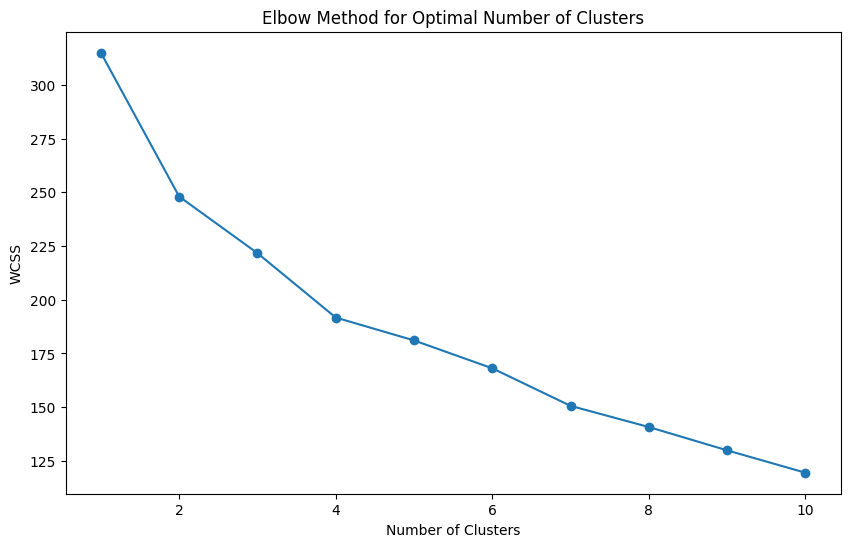


Cluster Characteristics:
         What percentage of your purchases are from companies that follow sustainability practices?  \
cluster                                                                                               
0.0                                              46.136364                                            
1.0                                              33.461538                                            
2.0                                              24.500000                                            

         What is the estimated increase in productivity you experience due to sustainability initiatives at your workplace?  \
cluster                                                                                                                       
0.0                                              16.590909                                                                    
1.0                                              11.923077                   

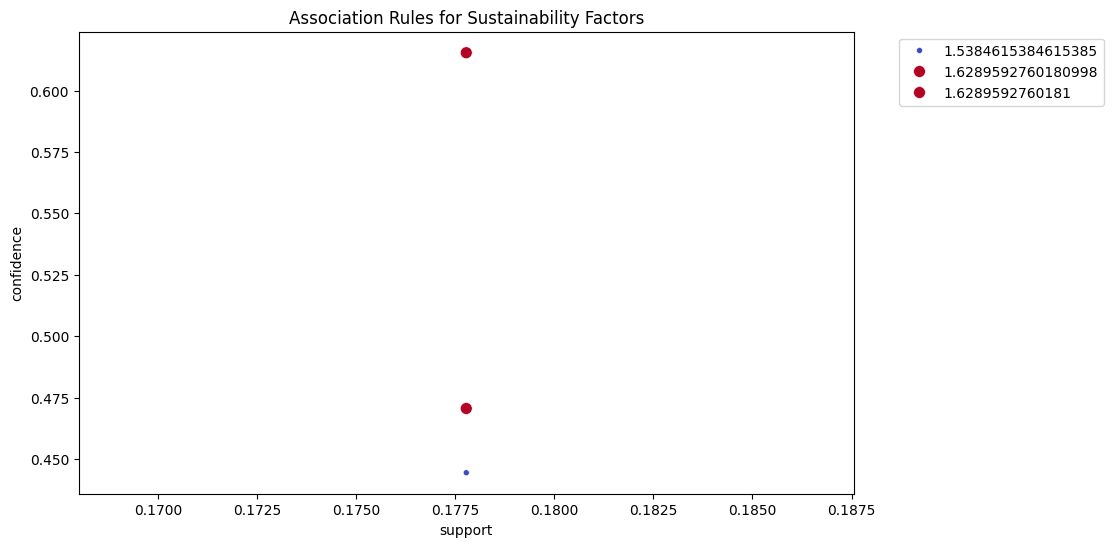


Feature Importances for Productivity Increase:
                                             feature  importance
0  What percentage of your purchases are from com...    0.242801
4  Do you believe corporations influence governme...    0.194665
1  What challenges do you foresee in adopting AI ...    0.167097
3  What would help SMEs (Small and Medium Enterpr...    0.156349
5  What factors make sustainable finance investme...    0.124093
2  Do you think SMEs (Small and Medium Enterprise...    0.114994


<ipython-input-2-dbeaad4210fd>:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette='rocket')


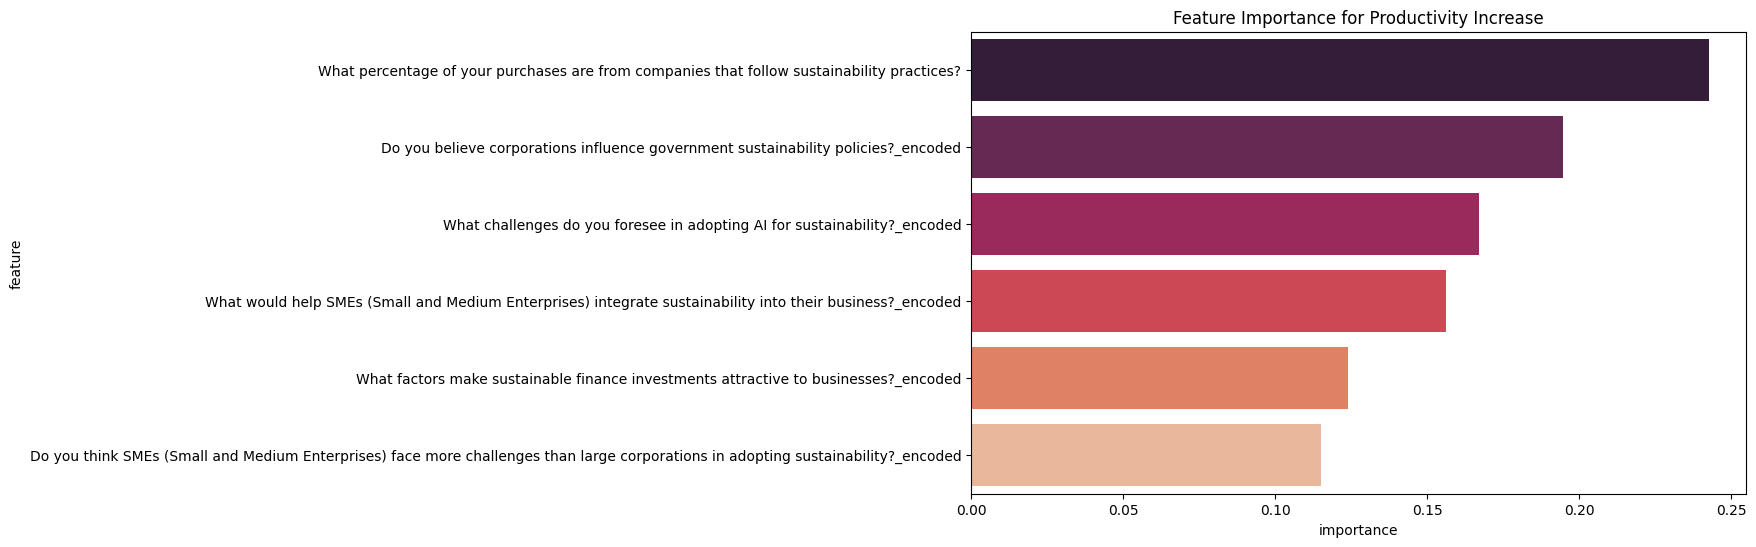

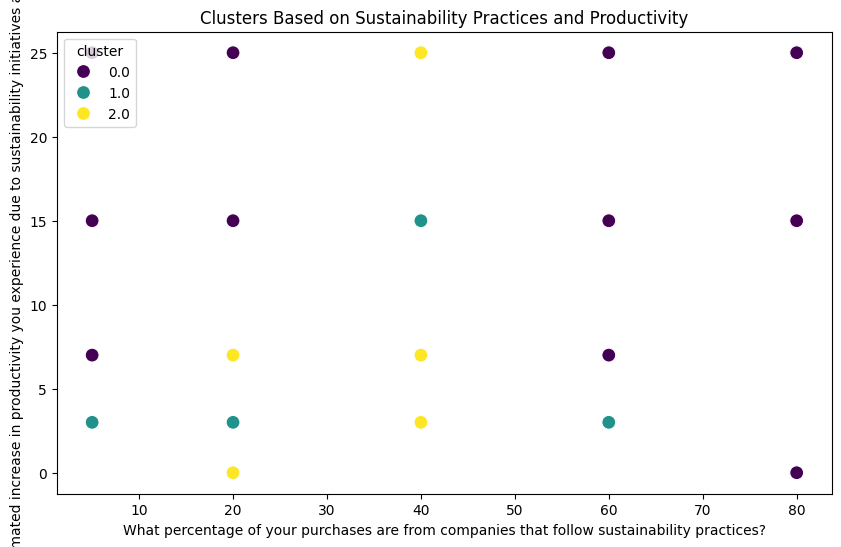

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('cleaned_sustainability_survey.csv')

# 1. DATA INSPECTION AND PREPARATION


# First, let's see what columns we actually have
print("Available columns in the dataset:")
print(df.columns.tolist())

# Identify which encoded columns exist
encoded_cols = [col for col in df.columns if '_encoded' in col]
print("\nAvailable encoded columns:")
print(encoded_cols)

# 2. CLUSTERING ANALYSIS (K-Means)


# Select only available numeric columns for clustering
cluster_features = []
potential_cluster_features = [
    'What percentage of your purchases are from companies that follow sustainability practices?',
    'What is the estimated increase in productivity you experience due to sustainability initiatives at your workplace?'
]

# Add encoded columns that exist
potential_cluster_features.extend(encoded_cols)

# Keep only columns that exist in the dataframe
cluster_features = [col for col in potential_cluster_features if col in df.columns]
cluster_df = df[cluster_features].dropna()

print("\nColumns used for clustering:")
print(cluster_features)

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# Determine optimal number of clusters using elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply K-Means with optimal clusters (let's assume 3 based on elbow)
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)

# Add cluster labels back to original dataframe (only for rows we clustered)
df.loc[cluster_df.index, 'cluster'] = cluster_labels

# Analyze cluster characteristics (using only numeric columns)
cluster_analysis = df.groupby('cluster')[cluster_features].mean()
print("\nCluster Characteristics:")
print(cluster_analysis)


# 3. ASSOCIATION RULE MINING (Apriori)


# Prepare data for association rules - use original text columns
categorical_cols = [
    'What influences your decision to support a company based on sustainability?',
    'Which industries should focus more on circular economy principles? ',
    'What would help SMEs (Small and Medium Enterprises) integrate sustainability into their business?'
]

# Filter to only include columns that exist
categorical_cols = [col for col in categorical_cols if col in df.columns]

# Create basket data
basket = pd.get_dummies(df[categorical_cols].apply(lambda x: x.astype(str)))

# Find frequent itemsets (adjust min_support as needed)
frequent_itemsets = apriori(basket, min_support=0.1, use_colnames=True)

# Generate association rules
if not frequent_itemsets.empty:  # Only proceed if we found itemsets
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
    print("\nTop Association Rules:")
    print(rules.sort_values('lift', ascending=False).head(10))

    # Association rules visualization
    plt.figure(figsize=(10, 6))
    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
    sns.scatterplot(data=rules, x='support', y='confidence', size='lift', hue='lift', palette='coolwarm')
    plt.title('Association Rules for Sustainability Factors')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
else:
    print("\nNo frequent itemsets found with current min_support threshold")


# 4. PREDICTIVE MODELING (Random Forest)

# Prepare data for predictive modeling - use available encoded columns
potential_features = [
    'What percentage of your purchases are from companies that follow sustainability practices?',
    *encoded_cols  # Include all available encoded columns
]

# Filter to only existing columns
X_cols = [col for col in potential_features if col in df.columns]
X = df[X_cols].dropna()

# Get target variable for the same rows
y = df.loc[X.index, 'What is the estimated increase in productivity you experience due to sustainability initiatives at your workplace?']

# Convert productivity increase into categories (0: <10%, 1: 10-20%, 2: >20%)
y = pd.cut(y, bins=[-1, 10, 20, 100], labels=[0, 1, 2]).dropna()

# Align X and y indices
X = X.loc[y.index]

if not X.empty:  # Only proceed if we have data
    # Train Random Forest model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)

    # Get feature importances
    importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
    importances = importances.sort_values('importance', ascending=False)
    print("\nFeature Importances for Productivity Increase:")
    print(importances)

    # Feature importance visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importances, x='importance', y='feature', palette='rocket')
    plt.title('Feature Importance for Productivity Increase')
    plt.show()
else:
    print("\nNot enough data for predictive modeling")


# 5. CLUSTER VISUALIZATION


if 'cluster' in df.columns:
    # Cluster visualization (only for rows with cluster labels)
    cluster_viz_df = df.dropna(subset=['cluster'])
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=cluster_viz_df,
                   x='What percentage of your purchases are from companies that follow sustainability practices?',
                   y='What is the estimated increase in productivity you experience due to sustainability initiatives at your workplace?',
                   hue='cluster',
                   palette='viridis',
                   s=100)
    plt.title('Clusters Based on Sustainability Practices and Productivity')
    plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



Top words per topic:
Topic #1: cost, product, green, business, large, smes, govt, sme, company, help
Topic #2: sustainability, overcome, term, cost, help, company, long, drive, customer, finance
Topic #3: lack, resource, expertise, investment, limited, smes, challenge, profitability, sustainability, make
Topic #4: incentive, government, tax, smes, invest, benefit, sustainability, profitability, finance, cost
Topic #5: cost, balance, government, sustainable, knowledge, training, support, make, profit, sme


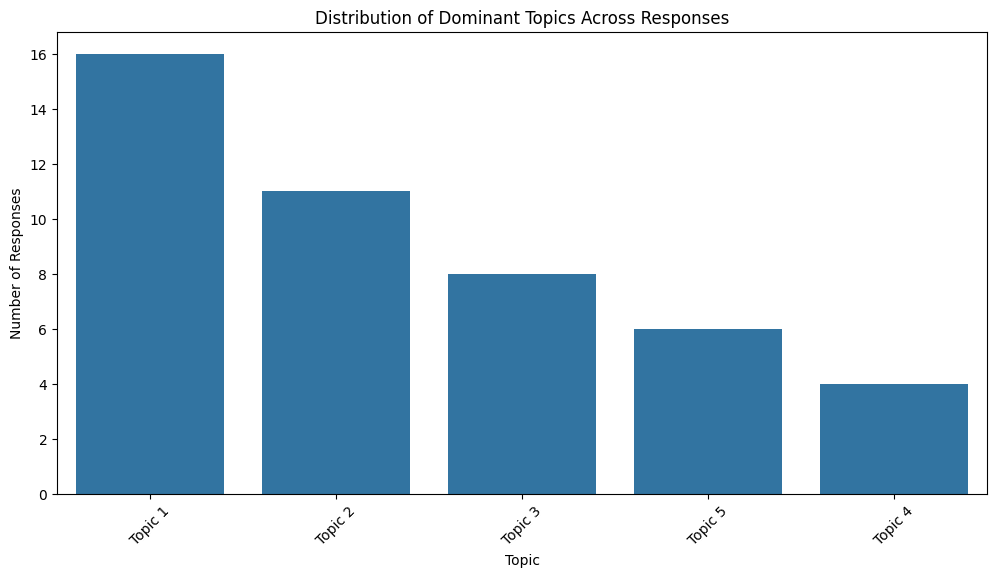

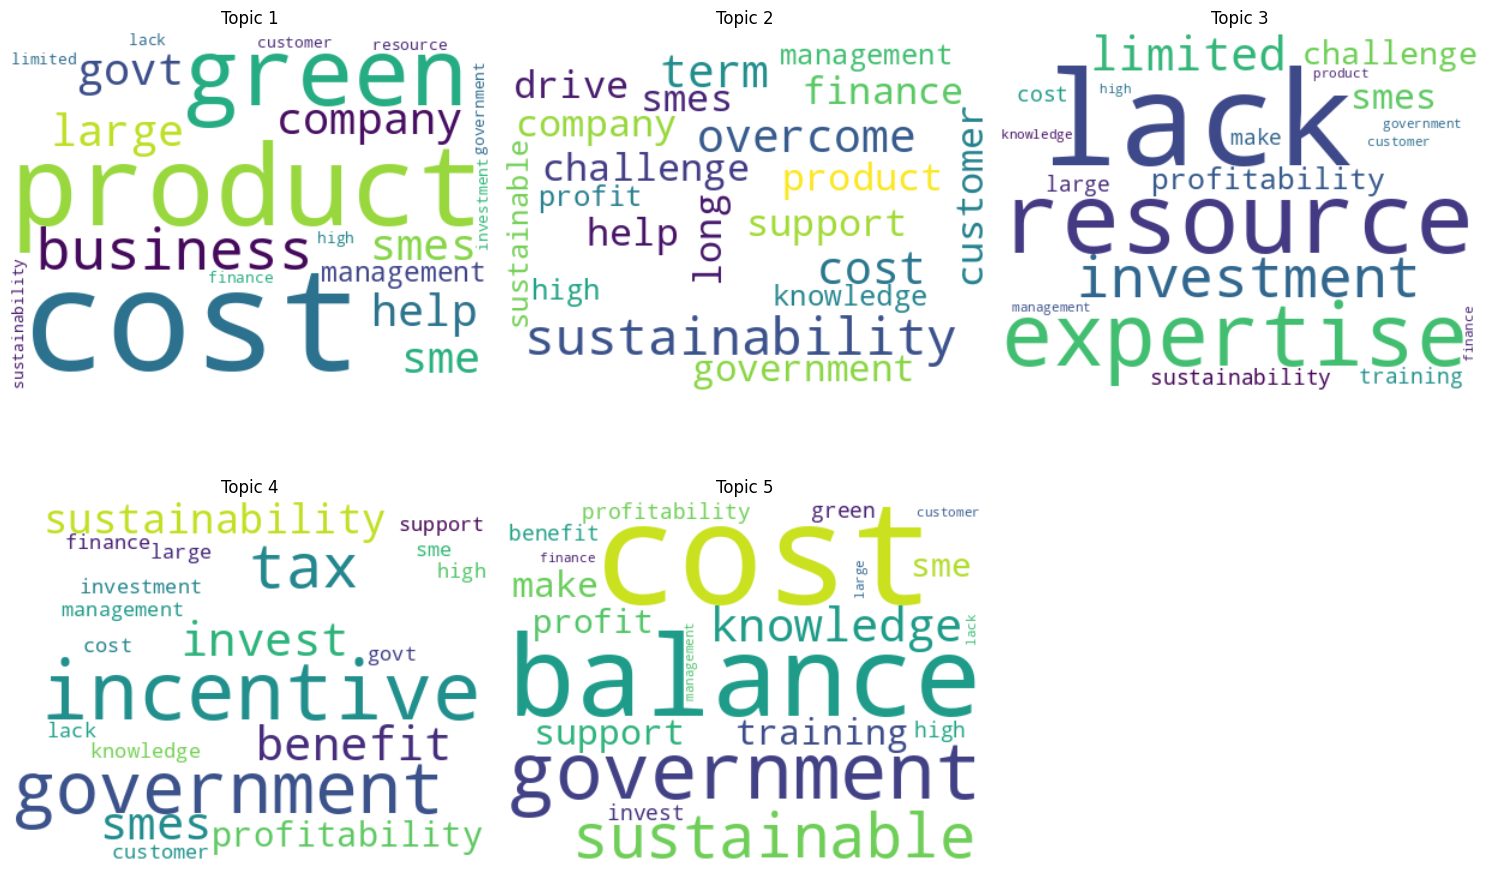


Sample data with assigned topics:
  What specific challenges do SMEs face in balancing profitability and sustainability, and how can they overcome them? (Short answer response)  \
0                                                NaN                                                                                             
1                    Government Should Support Smes.                                                                                             
2                             Capacity And Logistics                                                                                             
3                                           Not Sure                                                                                             
4  Smes Face Challenges Like Limited Resources, L...                                                                                             

  Dominant_Topic  
0        Topic 1  
1        Topic 2  
2        Topic 1  
3        Top

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load the cleaned dataset
df = pd.read_csv('cleaned_sustainability_survey.csv')

# 1. TEXT DATA PREPARATION
# Combine all text responses into a single corpus
text_columns = [
    "In your opinion, what's the biggest missing piece in corporate sustainability efforts today? (Short answer response)",
    "What specific challenges do SMEs face in balancing profitability and sustainability, and how can they overcome them? (Short answer response)",
    "What influences your decision to support a company based on sustainability?",
    "Which industries should focus more on circular economy principles?",
    "In your opinion, where can AI contribute most to sustainability?"
]

# Filter to only columns that exist in the dataframe
text_columns = [col for col in text_columns if col in df.columns]

# Combine text from all selected columns
corpus = df[text_columns].fillna('').apply(lambda x: ' '.join(x), axis=1)

# 2. TEXT PREPROCESSING
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Tokenize
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

# Apply preprocessing
processed_corpus = corpus.apply(preprocess_text)

# 3. TOPIC MODELING WITH LDA
# Create document-term matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
doc_term_matrix = vectorizer.fit_transform(processed_corpus)

# Train LDA model
num_topics = 5  # Adjust based on your needs
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(doc_term_matrix)

# 4. VISUALIZE TOPICS
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx + 1}: "
        message += ", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Print top words per topic
print("\nTop words per topic:")
print_top_words(lda_model, feature_names, 10)

# 5. TOPIC DISTRIBUTION VISUALIZATION
# Get topic distribution for documents
topic_distribution = lda_model.transform(doc_term_matrix)

# Create dataframe for visualization
topic_df = pd.DataFrame(topic_distribution, columns=[f"Topic {i+1}" for i in range(num_topics)])
topic_df['Dominant_Topic'] = topic_df.idxmax(axis=1)

# Plot topic distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=topic_df, x='Dominant_Topic', order=topic_df['Dominant_Topic'].value_counts().index)
plt.title('Distribution of Dominant Topics Across Responses')
plt.xlabel('Topic')
plt.ylabel('Number of Responses')
plt.xticks(rotation=45)
plt.show()

# 6. TOPIC WORD CLOUDS
# Requires wordcloud package: pip install wordcloud

try:
    from wordcloud import WordCloud

    plt.figure(figsize=(15, 10))
    for i in range(num_topics):
        # Create word cloud for each topic
        word_weights = {feature_names[j]: lda_model.components_[i][j] for j in lda_model.components_[i].argsort()[:-21:-1]}

        plt.subplot(2, 3, i+1)
        wordcloud = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(word_weights)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Topic {i+1}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

except ImportError:
    print("\nWordCloud package not installed. Install with: pip install wordcloud")

# 7. ASSIGN TOPICS TO ORIGINAL DATA
# Add dominant topic to original dataframe
df['Dominant_Topic'] = topic_df['Dominant_Topic']

# You can now analyze how topics relate to other variables
print("\nSample data with assigned topics:")
print(df[text_columns + ['Dominant_Topic']].head())